In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load generated data
accounts = pd.read_csv('D:/FraudRing/data/synthetic/v2/raw/accounts.csv')
merchants = pd.read_csv('D:/FraudRing/data/synthetic/v2/raw/merchants.csv')
transactions = pd.read_csv('D:/FraudRing/data/synthetic/v2/raw/transactions.csv')

with open('D:/FraudRing/data/synthetic/v2/ground_truth/fraud_rings.json', 'r') as f:
    import json
    fraud_rings_meta = json.load(f)

print("="*70)
print("DATA EXPLORATION SUMMARY")
print("="*70)
print(f"Accounts: {len(accounts):,}")
print(f"Merchants: {len(merchants):,}")
print(f"Transactions: {len(transactions):,}")
print(f"Fraud Rings: {len(fraud_rings_meta['rings'])}")
print(f"Fraud Transactions: {transactions['is_fraud'].sum():,}")
print(f"Fraud Ratio: {transactions['is_fraud'].mean()*100:.2f}%")
print("="*70)

DATA EXPLORATION SUMMARY
Accounts: 5,217
Merchants: 200
Transactions: 50,492
Fraud Rings: 45
Fraud Transactions: 2,992
Fraud Ratio: 5.93%


In [6]:
print("\n📊 Transaction Statistics:")
print(f"Mean amount: ${transactions['amount_usd'].mean():,.2f}")
print(f"Median amount: ${transactions['amount_usd'].median():,.2f}")
print(f"Std Dev: ${transactions['amount_usd'].std():,.2f}")
print(f"Min: ${transactions['amount_usd'].min():,.2f}")
print(f"Max: ${transactions['amount_usd'].max():,.2f}")


📊 Transaction Statistics:
Mean amount: $11,082.03
Median amount: $0.08
Std Dev: $53,177.42
Min: $0.02
Max: $678,011.35


In [7]:
print("\n📱 Channel Distribution:")
print(transactions['channel'].value_counts())


📱 Channel Distribution:
channel
online          23777
mobile          16576
atm              4741
peer_to_peer     2992
branch           2406
Name: count, dtype: int64


In [8]:
transactions['hour'] = pd.to_datetime(transactions['timestamp']).dt.hour
print("\n⏰ Transactions by Hour:")
print(transactions['hour'].value_counts().sort_index())


⏰ Transactions by Hour:
hour
0      391
1      345
2      303
3      361
4      302
5      321
6      260
7      299
8     4499
9     4509
10    4411
11    4444
12    4531
13    4414
14    4638
15    4523
16    4668
17    4507
18     570
19     470
20     475
21     429
22     439
23     383
Name: count, dtype: int64


In [9]:
print("\n🔄 Fraud Ring Statistics:")
for i, ring in enumerate(fraud_rings_meta['rings'][:5]):
    print(f"\nRing {i+1}:")
    print(f"  Type: {ring['ring_type']}")
    print(f"  Participants: {ring['participant_count']}")
    print(f"  Transactions: {ring['transactions']}")
    print(f"  Amount: ${ring['total_amount']:,.2f}")



🔄 Fraud Ring Statistics:

Ring 1:
  Type: money_laundering
  Participants: 3
  Transactions: 18
  Amount: $624,731.25

Ring 2:
  Type: account_takeover
  Participants: 3
  Transactions: 24
  Amount: $1,257,501.63

Ring 3:
  Type: collusion
  Participants: 3
  Transactions: 30
  Amount: $2,241,114.54

Ring 4:
  Type: account_takeover
  Participants: 3
  Transactions: 15
  Amount: $399,291.39

Ring 5:
  Type: collusion
  Participants: 3
  Transactions: 30
  Amount: $2,153,116.32



✓ Saved exploration plots to results/data_exploration.png


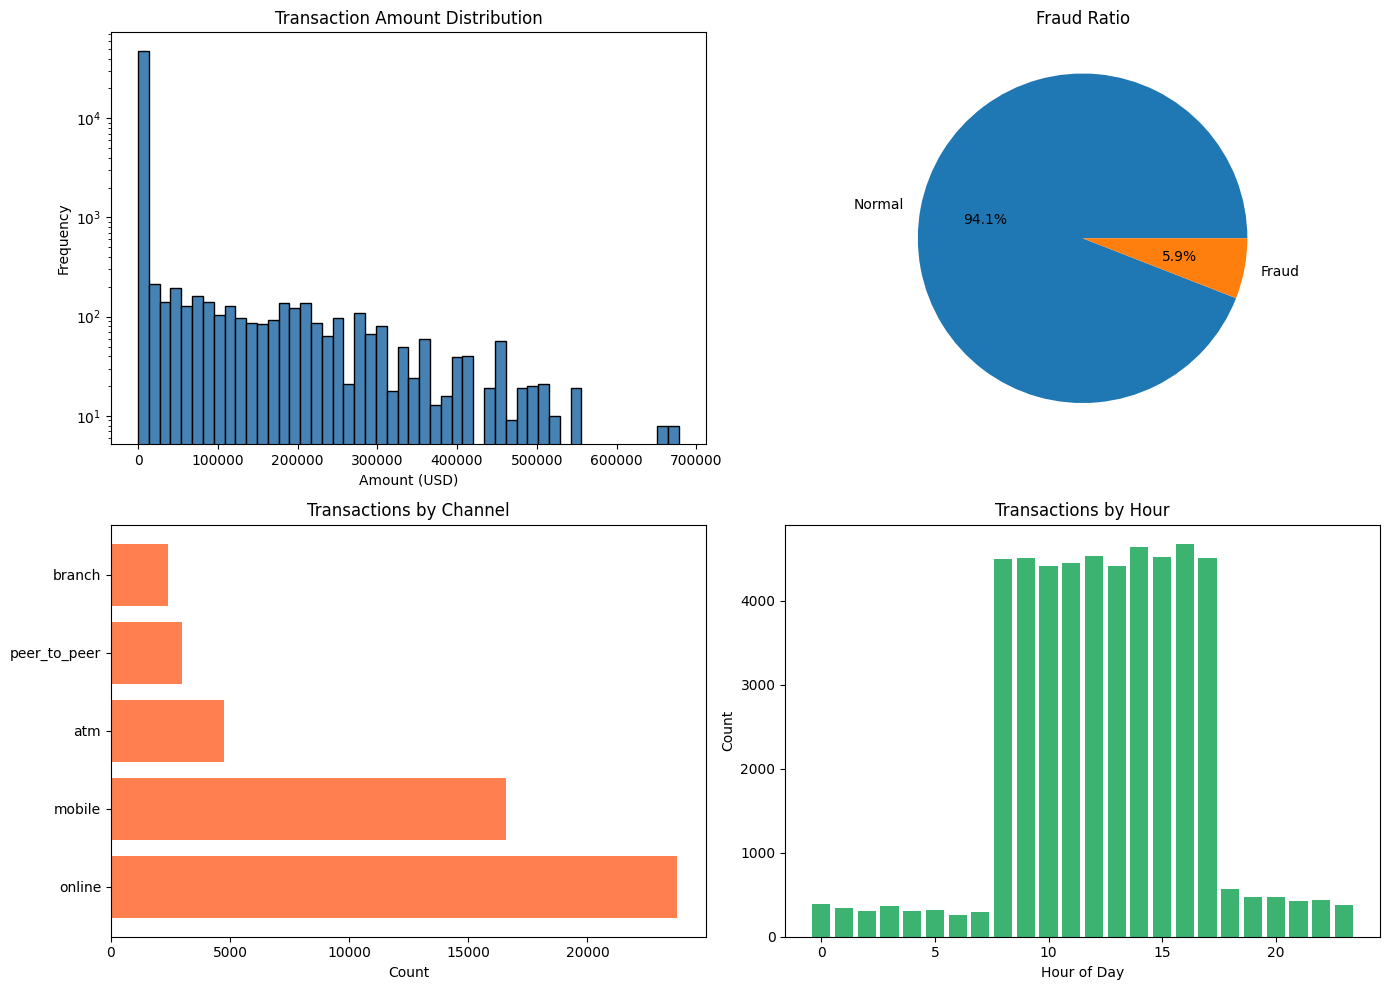

In [13]:
# CELL 6: Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Transaction amount distribution
axes[0, 0].hist(transactions['amount_usd'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Amount (USD)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Transaction Amount Distribution')
axes[0, 0].set_yscale('log')

# Plot 2: Fraud vs Normal
fraud_counts = transactions['is_fraud'].value_counts()
axes[0, 1].pie(fraud_counts.values, labels=['Normal', 'Fraud'], autopct='%1.1f%%')
axes[0, 1].set_title('Fraud Ratio')

# Plot 3: Transactions by Channel
channel_counts = transactions['channel'].value_counts()
axes[1, 0].barh(channel_counts.index, channel_counts.values, color='coral')
axes[1, 0].set_xlabel('Count')
axes[1, 0].set_title('Transactions by Channel')

# Plot 4: Transactions by Hour
hourly = transactions['hour'].value_counts().sort_index()
axes[1, 1].bar(hourly.index, hourly.values, color='mediumseagreen')
axes[1, 1].set_xlabel('Hour of Day')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Transactions by Hour')

plt.tight_layout()
plt.savefig('D:\\FraudRing\\results\\data_exploration.png', dpi=150, bbox_inches='tight')
print("\n✓ Saved exploration plots to results/data_exploration.png")

In [14]:
print("\n✅ Data Quality Checks:")
print(f"Duplicate transaction IDs: {transactions['transaction_id'].duplicated().sum()}")
print(f"Duplicate account IDs: {accounts['account_id'].duplicated().sum()}")
print(f"Missing values in transactions: {transactions.isnull().sum().sum()}")
print(f"Negative amounts: {(transactions['amount_usd'] < 0).sum()}")
print(f"Invalid timestamps: {pd.to_datetime(transactions['timestamp'], errors='coerce').isnull().sum()}")
print("✓ All checks passed!")


✅ Data Quality Checks:
Duplicate transaction IDs: 0
Duplicate account IDs: 0
Missing values in transactions: 95000
Negative amounts: 0
Invalid timestamps: 0
✓ All checks passed!
